In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import lakefs_spec
from dotenv import load_dotenv

In [2]:
# Load data using lakefs
LAKEFS_REPO = "athletes"
lakefs_uri = lakefs_uri = f"lakefs://{LAKEFS_REPO}/v1/athletes_v1.csv"

# Open file using lakefs
fs = lakefs_spec.LakeFSFileSystem()

with fs.open(lakefs_uri, "rb") as f:
    df = pd.read_csv(f)

# Load data using DVC after git checkout v1 and dvc checkout
# df = pd.read_csv('athletes.csv')

print(f"Loaded dataset v1.")

Loaded dataset v1.


## Calculate total_lift and train-test split

In [4]:
# Total lift
df['total_lift'] = df['deadlift'] + df['candj'] + df['snatch'] + df['backsq']

In [5]:
# Train test split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=32021)

## EDA

In [7]:
df.head()

,athlete_id,name,region,team,affiliate,gender,age,height,weight,fran,...,deadlift,backsq,pullups,eat,train,background,experience,schedule,howlong,total_lift
0,2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,NaN,...,400.0,305.0,NaN,NaN,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I r...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|,NaN
1,3517.0,Derek Abdella,NaN,NaN,NaN,Male,42.0,70.0,190.0,NaN,...,NaN,NaN,NaN,NaN,I have a coach who determines my programming|I...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|,NaN
2,4691.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,NaN,211.0,...,375.0,325.0,25.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|,4+ years|,1145.0
4,5286.0,Bryce Abbey,NaN,NaN,NaN,Male,32.0,65.0,149.0,206.0,...,NaN,325.0,50.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I inc...,I played college sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I strictly s...,1-2 years|,NaN


In [8]:
print("Train data shape:", df_train.shape)
df_train.info()

Train data shape: (338404, 28)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 338404 entries, 92741 to 208064
Data columns (total 28 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   athlete_id  338401 non-null  float64
 1   name        264789 non-null  object 
 2   region      201041 non-null  object 
 3   team        124114 non-null  object 
 4   affiliate   193552 non-null  object 
 5   gender      264789 non-null  object 
 6   age         264789 non-null  float64
 7   height      127755 non-null  float64
 8   weight      183821 non-null  float64
 9   fran        44362 non-null   float64
 10  helen       24201 non-null   float64
 11  grace       32668 non-null   float64
 12  filthy50    15633 non-null   float64
 13  fgonebad    23832 non-null   float64
 14  run400      17802 non-null   float64
 15  run5k       29006 non-null   float64
 16  candj       83509 non-null   float64
 17  snatch      77768 non-null   float64
 18  deadlift 

In [9]:
# Missing values
df_train.isnull().sum()

athlete_id         3
name           73615
region        137363
team          214290
affiliate     144852
gender         73615
age            73615
height        210649
weight        154583
fran          294042
helen         314203
grace         305736
filthy50      322771
fgonebad      314572
run400        320602
run5k         309398
candj         254895
snatch        260636
deadlift      246091
backsq        250021
pullups       297908
eat           263237
train         253706
background    259181
experience    254422
schedule      260126
howlong       251033
total_lift    270275
dtype: int64

In [10]:
# Summary statistics
df_train.describe()

,athlete_id,age,height,weight,fran,helen,grace,filthy50,fgonebad,run400,run5k,candj,snatch,deadlift,backsq,pullups,total_lift
count,338401.000000,264789.000000,1.277550e+05,183821.000000,4.436200e+04,2.420100e+04,3.266800e+04,15633.000000,2.383200e+04,1.780200e+04,2.900600e+04,83509.000000,77768.000000,9.231300e+04,8.838300e+04,4.049600e+04,6.812900e+04
mean,292622.668311,32.526295,1.337777e+02,170.968790,9.621631e+02,1.004152e+03,6.631447e+02,1712.968144,1.370924e+03,6.137719e+02,3.590387e+03,191.274198,146.294774,6.060373e+02,4.695965e+02,5.332532e+04,1.585075e+03
std,184884.867945,7.727874,2.346915e+04,62.517501,6.993955e+04,5.402983e+04,5.462412e+04,6366.453692,9.433269e+04,6.290537e+04,1.306860e+05,869.823645,525.825165,4.781881e+04,3.999086e+04,1.067157e+07,9.647408e+04
min,82.000000,13.000000,0.000000e+00,1.000000,1.000000e+00,1.000000e+00,-6.000000e+01,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,-45.000000,0.000000,-1.100000e+01,0.000000e+00,-6.000000e+00,-2.200000e+01
25%,135093.000000,27.000000,6.600000e+01,145.000000,2.150000e+02,5.240000e+02,1.490000e+02,1307.000000,2.400000e+02,6.200000e+01,1.242250e+03,143.000000,105.000000,2.550000e+02,2.050000e+02,1.500000e+01,7.350000e+02
50%,275660.000000,31.000000,6.900000e+01,170.000000,2.900000e+02,5.930000e+02,1.930000e+02,1550.000000,2.940000e+02,7.100000e+01,1.380000e+03,195.000000,145.000000,3.450000e+02,2.750000e+02,2.700000e+01,9.870000e+02
75%,473035.000000,37.000000,7.200000e+01,192.000000,3.920000e+02,6.920000e+02,2.620000e+02,1813.000000,3.360000e+02,8.400000e+01,1.560000e+03,235.000000,185.000000,4.150000e+02,3.350000e+02,3.900000e+01,1.185000e+03
max,632958.000000,125.000000,8.388607e+06,20175.000000,8.388607e+06,8.388607e+06,8.388607e+06,600039.000000,8.388607e+06,8.388607e+06,8.388607e+06,250235.000000,145155.000000,8.388607e+06,8.388607e+06,2.147484e+09,1.678231e+07


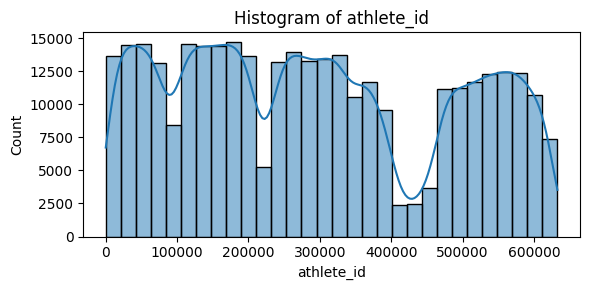

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

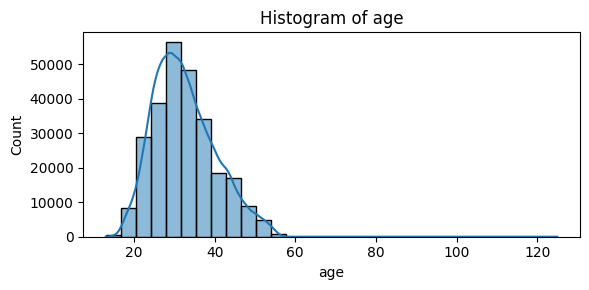

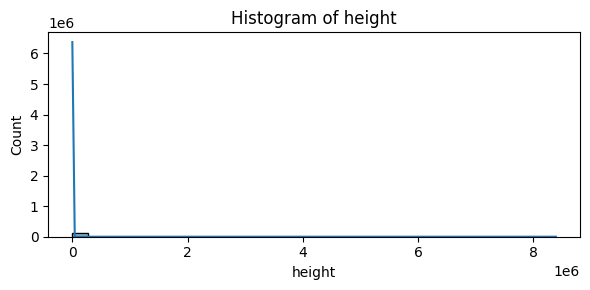

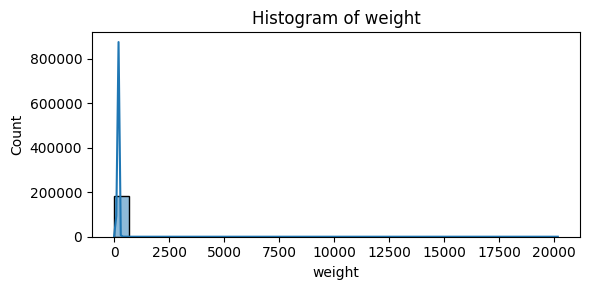

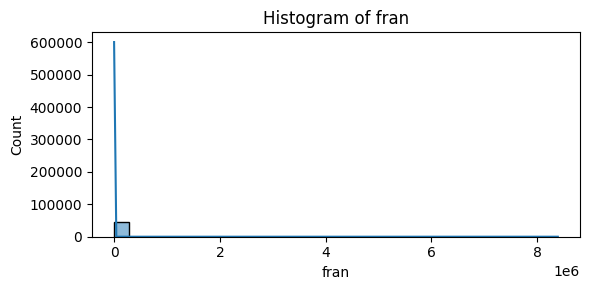

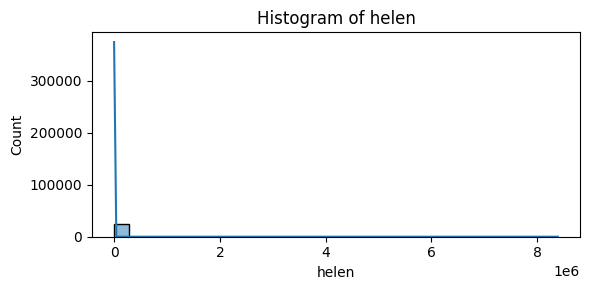

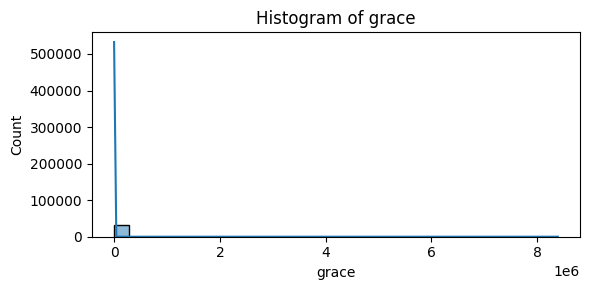

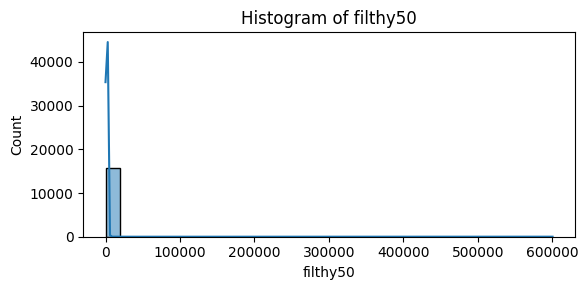

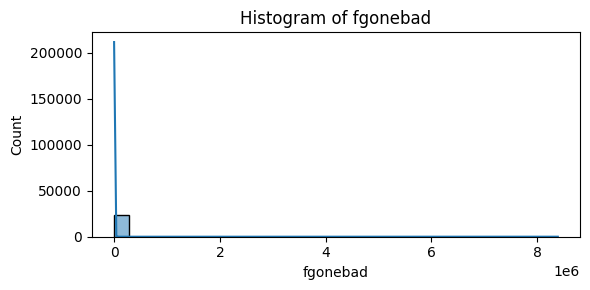

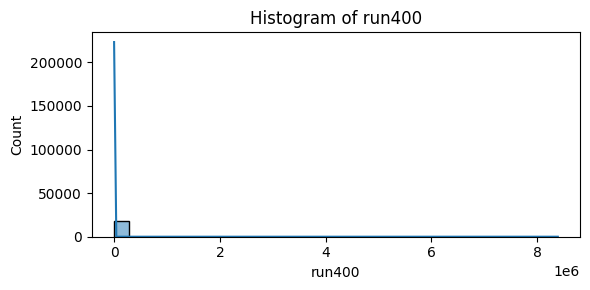

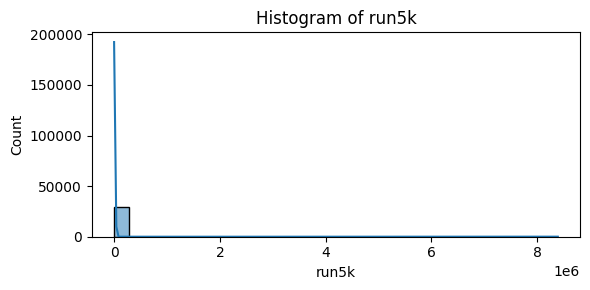

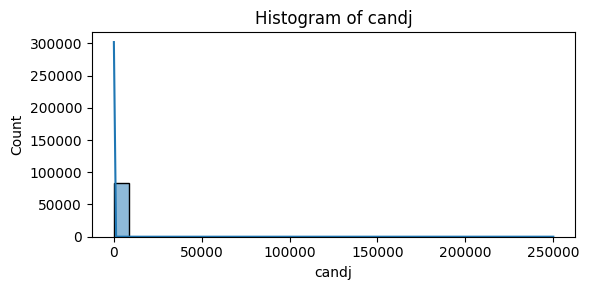

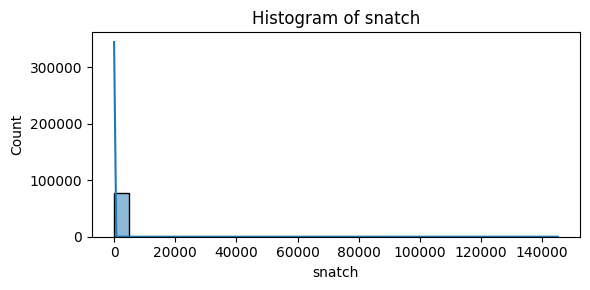

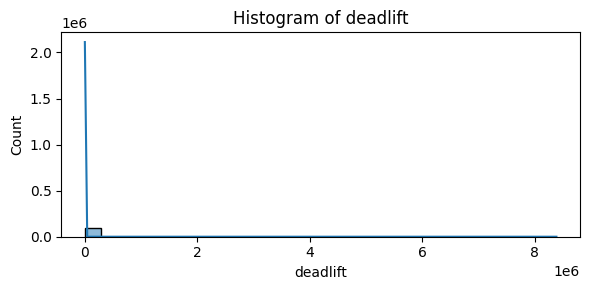

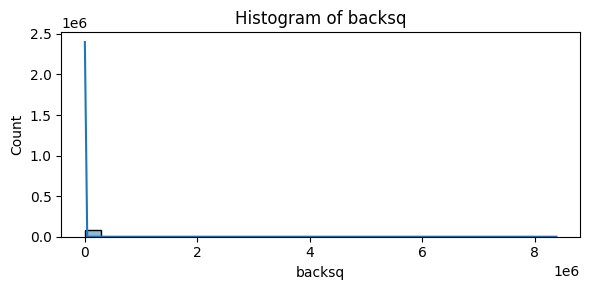

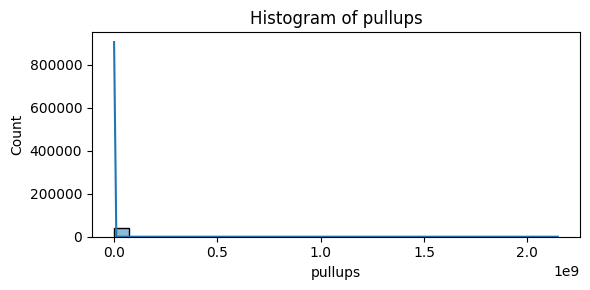

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

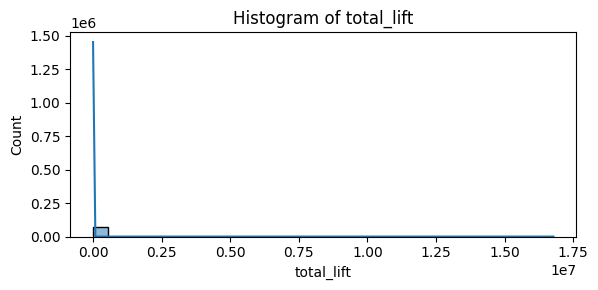

In [11]:
for col in df_train.columns:
    plt.figure(figsize=(6, 3))
    
    if df_train[col].dtype in ['int64', 'float64']:
        sns.histplot(df_train[col], kde=True, bins=30)
        plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show()

/var/folders/kf/8ms7_h8j11bf86d6c5ykldrw0000gn/T/ipykernel_51954/4151145974.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_mat = df_train.corr()


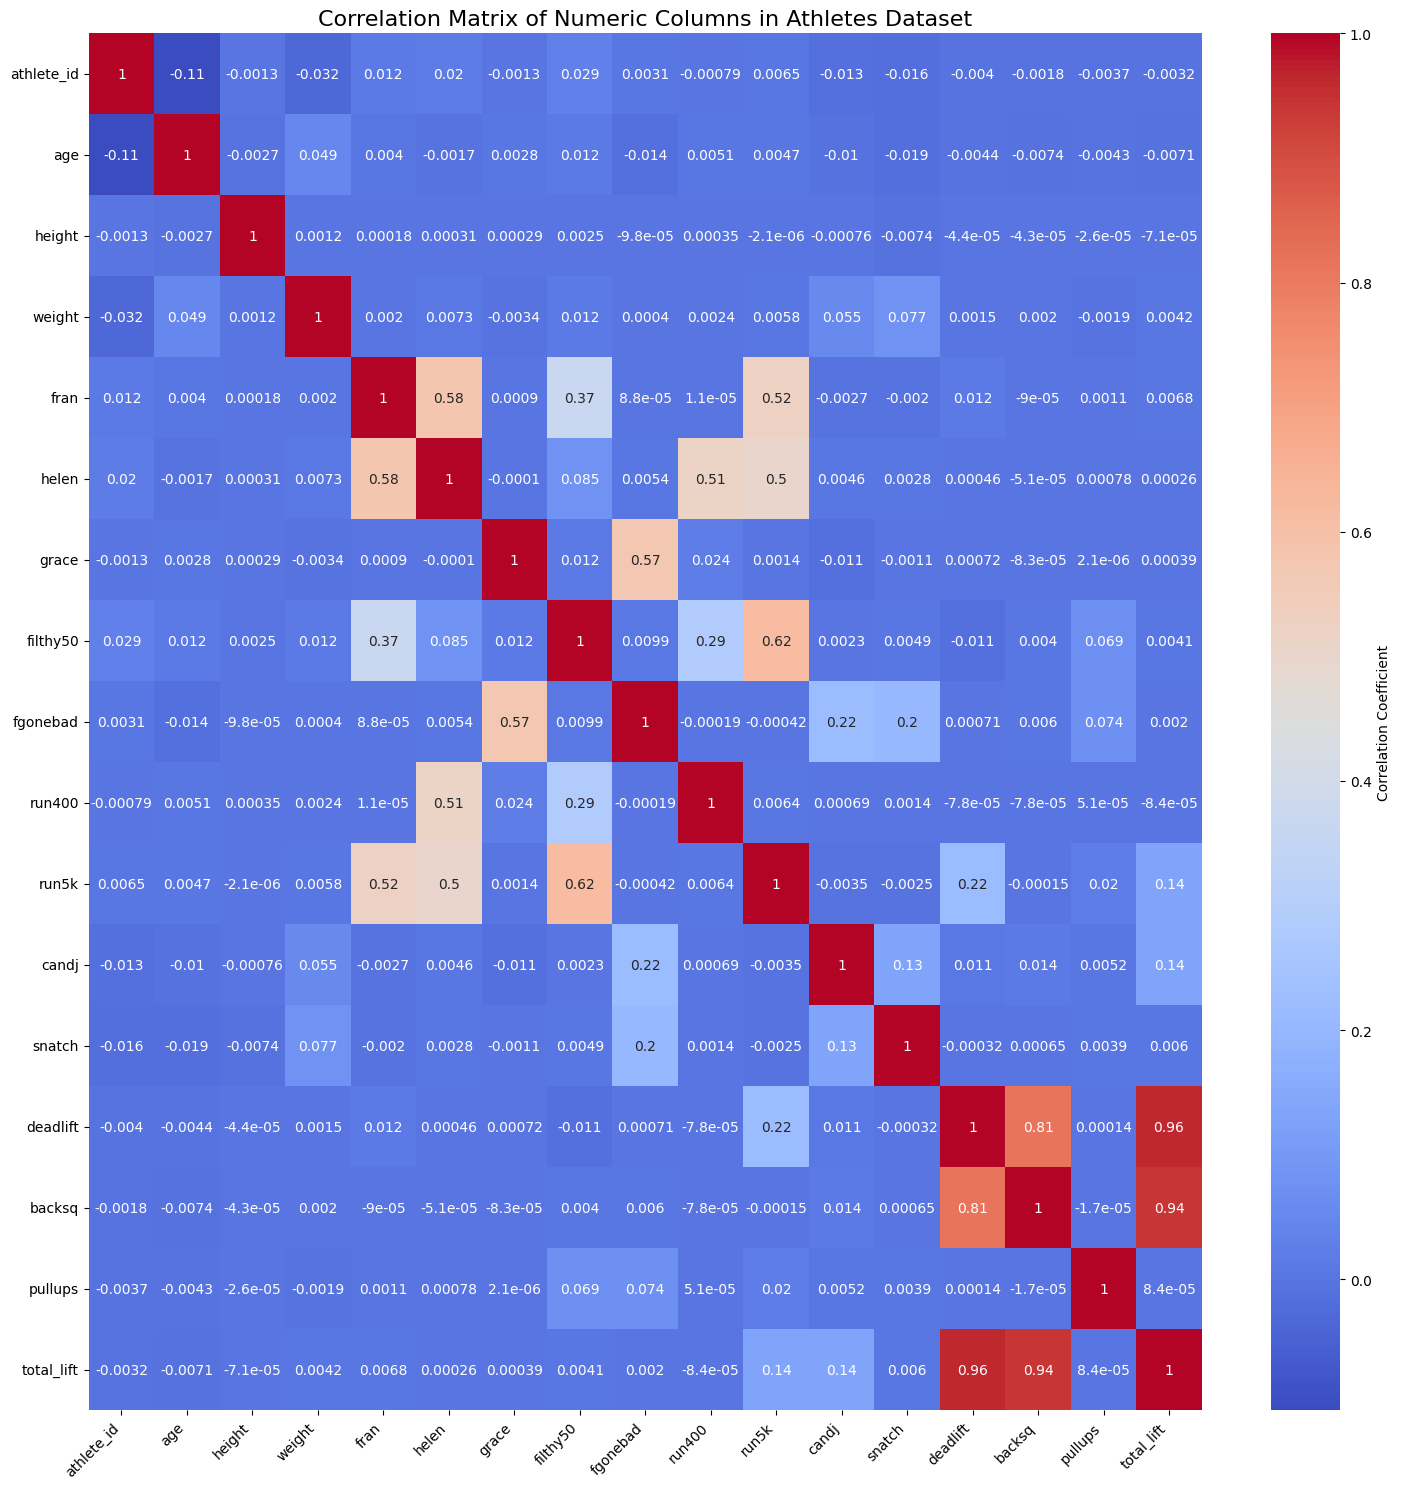

In [12]:
corr_mat = df_train.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr_mat,annot=True,cmap='coolwarm',cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numeric Columns in Athletes Dataset', fontsize=16)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)      
plt.tight_layout()
plt.show()

## Model

In [14]:
df_train = df_train.dropna(subset=['total_lift'])
df_test = df_test.dropna(subset=['total_lift'])

target = 'total_lift'

X_train = df_train.drop(columns=[target])
y_train = df_train[target]

X_test = df_test.drop(columns=[target])
y_test = df_test[target]

In [15]:
# Numeric and categorical predictors
num_vars = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_vars = ['gender','howlong']

In [16]:
# Keep only relevant predictors
X_train = X_train[num_vars + cat_vars]
X_test = X_test[num_vars + cat_vars]

num_imputer = SimpleImputer(strategy='median')
X_train[num_vars] = num_imputer.fit_transform(X_train[num_vars])
X_test[num_vars] = num_imputer.transform(X_test[num_vars])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_vars] = cat_imputer.fit_transform(X_train[cat_vars])
X_test[cat_vars] = cat_imputer.transform(X_test[cat_vars])

In [17]:
# Encode categorical
X_train = pd.get_dummies(X_train, columns=cat_vars)
X_test = pd.get_dummies(X_test, columns=cat_vars)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [18]:
model = RandomForestRegressor(random_state=32021)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Metrics:")
print("R^2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mse)
print("RMSE:", rmse)

Metrics:
R^2 score: 0.767873540433399
MAE: 1187.094463134451
MSE: 19161968735.957455
RMSE: 138426.76307693342
